<a href="https://colab.research.google.com/github/grasschopper123/ECONML-Project/blob/main/lab_9_25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 0. Assessing Logistic Regression

This time we will use the Ames Housing Data from OPENML

In [1]:
# Install the openml package
!pip install openml

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.4/160.4 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.8/93.8 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 28.2 MB/s eta 0:00:00
  Created wheel for liac-arff: filename=liac_arff-2.5.0-py3-none-any.whl size=11771 sha256=81938631a3409e8911e6c513e15cadede343238a3afbdbf192f5c7faba692705
  Stored in directory: /root/.cache/pip/wheels/93/f3/5b/658a9bddee916a5f4b84bdc1a4e0fabd22fb17947c2c9542e6
Successfully built liac-arff


In [2]:
import openml
# find the data in their database
dataset = openml.datasets.get_dataset('ames_housing')

In [3]:
# transform the data into dataframe format. Now it is given the name "X"
X, y, _, _ = dataset.get_data(dataset_format="dataframe")

In [4]:
y = X['Sale_Price']
X = X.drop('Sale_Price', axis=1)

We have now separated the target variable `y` (Sale_Price) from the feature set `X`.

In [5]:
import pandas as pd
X_encoded = pd.get_dummies(X, drop_first=True)
display(X_encoded.head())

,Lot_Frontage,Lot_Area,Year_Built,Year_Remod_Add,Mas_Vnr_Area,BsmtFin_SF_1,BsmtFin_SF_2,Bsmt_Unf_SF,Total_Bsmt_SF,First_Flr_SF,...,Sale_Type_CWD,Sale_Type_New,Sale_Type_Oth,Sale_Type_VWD,Sale_Type_WD,Sale_Condition_AdjLand,Sale_Condition_Alloca,Sale_Condition_Family,Sale_Condition_Normal,Sale_Condition_Partial
0,141.0,31770.0,1960.0,1960.0,112.0,2,0.0,441.0,1080.0,1656.0,...,False,False,False,False,True,False,False,False,True,False
1,80.0,11622.0,1961.0,1961.0,0.0,6,144.0,270.0,882.0,896.0,...,False,False,False,False,True,False,False,False,True,False
2,81.0,14267.0,1958.0,1958.0,108.0,1,0.0,406.0,1329.0,1329.0,...,False,False,False,False,True,False,False,False,True,False
3,93.0,11160.0,1968.0,1968.0,0.0,1,0.0,1045.0,2110.0,2110.0,...,False,False,False,False,True,False,False,False,True,False
4,74.0,13830.0,1997.0,1998.0,0.0,3,0.0,137.0,928.0,928.0,...,False,False,False,False,True,False,False,False,True,False


We have successfully converted our categorical features into a numerical format using one-hot encoding. Each original categorical column has been replaced by several new binary columns, and `drop_first=True` was used to avoid multicollinearity issues by dropping the first category of each feature.

In [6]:
X = X_encoded
print(f"New shape of X after one-hot encoding: {X.shape}")

New shape of X after one-hot encoding: (2930, 308)


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (2344, 308)
X_test shape: (586, 308)
y_train shape: (2344,)
y_test shape: (586,)


In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrames, preserving column names
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Scaled X_train_scaled_df head:")
display(X_train_scaled_df.head())

print("\nScaled X_test_scaled_df head:")
display(X_test_scaled_df.head())

Scaled X_train_scaled_df head:


,Lot_Frontage,Lot_Area,Year_Built,Year_Remod_Add,Mas_Vnr_Area,BsmtFin_SF_1,BsmtFin_SF_2,Bsmt_Unf_SF,Total_Bsmt_SF,First_Flr_SF,...,Sale_Type_CWD,Sale_Type_New,Sale_Type_Oth,Sale_Type_VWD,Sale_Type_WD,Sale_Condition_AdjLand,Sale_Condition_Alloca,Sale_Condition_Family,Sale_Condition_Normal,Sale_Condition_Partial
381,0.667826,0.033810,0.181084,-0.381277,0.531409,1.268224,-0.293998,1.235361,0.099389,0.558877,...,-0.071734,-0.281407,-0.054729,-0.020659,0.381641,-0.058521,-0.087969,7.494714,-2.197919,-0.285797
834,-1.717704,2.307082,-0.115603,-0.814347,-0.569155,-0.075073,4.191480,-1.277583,-0.076847,0.013468,...,-0.071734,-0.281407,-0.054729,-0.020659,0.381641,-0.058521,-0.087969,-0.133427,-2.197919,-0.285797
1898,0.369635,-0.035514,-0.280430,-1.054941,-0.569155,0.372692,-0.293998,-1.277583,-2.395369,0.179688,...,-0.071734,-0.281407,-0.054729,-0.020659,0.381641,-0.058521,-0.087969,-0.133427,0.454976,-0.285797
678,0.071444,-0.363746,-0.708978,-1.632368,-0.569155,0.372692,-0.293998,-1.277583,-2.395369,-0.298194,...,-0.071734,-0.281407,-0.054729,-0.020659,0.381641,-0.058521,-0.087969,-0.133427,0.454976,-0.285797
700,0.160901,-0.310697,-1.664971,-1.632368,-0.569155,1.268224,-0.293998,0.105689,-1.022108,-0.139766,...,-0.071734,-0.281407,-0.054729,-0.020659,0.381641,-0.058521,-0.087969,-0.133427,0.454976,-0.285797



Scaled X_test_scaled_df head:


,Lot_Frontage,Lot_Area,Year_Built,Year_Remod_Add,Mas_Vnr_Area,BsmtFin_SF_1,BsmtFin_SF_2,Bsmt_Unf_SF,Total_Bsmt_SF,First_Flr_SF,...,Sale_Type_CWD,Sale_Type_New,Sale_Type_Oth,Sale_Type_VWD,Sale_Type_WD,Sale_Condition_AdjLand,Sale_Condition_Alloca,Sale_Condition_Family,Sale_Condition_Normal,Sale_Condition_Partial
1357,-1.717704,-0.624641,-1.500145,0.581101,-0.569155,1.268224,-0.293998,0.078023,-1.049573,-0.835812,...,-0.071734,-0.281407,-0.054729,-0.020659,0.381641,-0.058521,-0.087969,-0.133427,0.454976,-0.285797
2367,-1.091502,-1.023439,0.049223,-0.573752,1.643619,-1.418371,-0.293998,-0.788827,-1.264718,-1.716258,...,-0.071734,-0.281407,-0.054729,-0.020659,0.381641,-0.058521,-0.087969,-0.133427,0.454976,-0.285797
2822,0.131082,-0.368467,1.071146,0.966053,0.537232,1.268224,-0.293998,0.557558,-0.573509,-0.905936,...,-0.071734,-0.281407,-0.054729,-0.020659,0.381641,-0.058521,-0.087969,-0.133427,0.454976,-0.285797
2126,0.071444,-0.255660,0.774459,0.532983,-0.569155,-0.522839,-0.293998,-0.350791,-0.129488,-0.428054,...,-0.071734,-0.281407,-0.054729,-0.020659,0.381641,-0.058521,-0.087969,-0.133427,0.454976,-0.285797
1544,-0.226747,-0.388593,-1.467179,0.677339,-0.569155,0.820458,-0.059156,0.001944,-0.349210,-0.612454,...,-0.071734,-0.281407,-0.054729,-0.020659,0.381641,-0.058521,-0.087969,-0.133427,0.454976,-0.285797


## Logistic Regression for Classification (Demonstration)

Since logistic regression is a classification algorithm, we first need to convert our continuous target variable (`Sale_Price`) into a binary categorical variable. We'll define a new target, `is_expensive`, where houses with a `Sale_Price` above the median are considered 'expensive' (1) and those below or equal are 'not expensive' (0).

```markdown
*create a new binary y variable "is_expensive" that takes value 1 if sale price is above median and 0 otherwise. *
```
___

In [9]:
y_median = y.median()
y_binary = (y > y_median).astype(int)
display(y_binary.head())

,Sale_Price
0,1
1,0
2,1
3,1
4,1


```markdown
*logistically regress the new target "is_expensive" on the X variables, then report accuracy, precision recall, and roc auc score.*
```
___

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split

# Split the binary target variable using the same split as X and y
_, _, y_train_binary, y_test_binary = train_test_split(X, y_binary, test_size=0.2, random_state=42)

# Initialize and train the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # Using liblinear for smaller datasets
log_reg_model.fit(X_train_scaled_df, y_train_binary)

# Make predictions on the test set
y_pred_log_reg = log_reg_model.predict(X_test_scaled_df)
y_pred_proba_log_reg = log_reg_model.predict_proba(X_test_scaled_df)[:, 1]

# Calculate evaluation metrics
accuracy = accuracy_score(y_test_binary, y_pred_log_reg)
precision = precision_score(y_test_binary, y_pred_log_reg)
recall = recall_score(y_test_binary, y_pred_log_reg)
f1 = f1_score(y_test_binary, y_pred_log_reg)
roc_auc = roc_auc_score(y_test_binary, y_pred_proba_log_reg)

# Report the metrics
print(f"Logistic Regression Model Performance:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC AUC Score: {roc_auc:.4f}")

Logistic Regression Model Performance:
Accuracy: 0.9334
Precision: 0.9404
Recall: 0.9311
F1-Score: 0.9357
ROC AUC Score: 0.9829


### 0.1 Confusion Matrix

A confusion matrix is a table that is often used to describe the performance of a classification model on a set of test data for which the true values are known. It allows visualization of the performance of an algorithm. Each row of the matrix represents the instances in an actual class while each column represents the instances in a predicted class, or vice versa.

```markdown
*plot the confusion matrix*
```
___

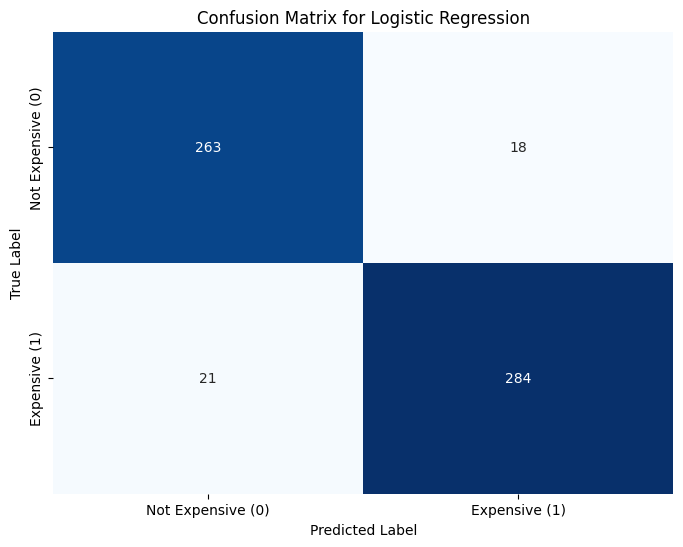

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate the confusion matrix
cm = confusion_matrix(y_test_binary, y_pred_log_reg)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Expensive (0)', 'Expensive (1)'],
            yticklabels=['Not Expensive (0)', 'Expensive (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Logistic Regression')
plt.show()

### 0.2 Comparing Logistic Regression with Other Classifiers and a Baseline

To put the logistic regression model's performance into perspective, let's compare its metrics with a simple baseline model (a `DummyClassifier`) and a few other common classification algorithms such as K-Nearest Neighbors and Decision Tree.

```markdown
*compare the accuracy, precision, recall and roc auc for the logistic regression, a simple baseline model, KNN and decision tree*
```
___

In [12]:
from sklearn.dummy import DummyClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

# Dictionary to store model results
model_comparison = {}

# Add Logistic Regression results (already computed)
model_comparison['Logistic Regression'] = {
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'ROC AUC': roc_auc
}

# 1. Dummy Classifier (Baseline)
dummy_model = DummyClassifier(strategy='most_frequent', random_state=42)
dummy_model.fit(X_train_scaled_df, y_train_binary)
y_pred_dummy = dummy_model.predict(X_test_scaled_df)
# DummyClassifier does not have predict_proba for 'most_frequent' strategy, use a placeholder or handle gracefully
# For simplicity, we'll assign a ROC AUC of 0.5 for a 'most_frequent' dummy classifier as it's essentially random for binary. Or just skip ROC AUC if strategy is not 'stratified'.
# Let's use 'stratified' for ROC AUC or skip it for 'most_frequent'

dummy_accuracy = accuracy_score(y_test_binary, y_pred_dummy)
dummy_precision = precision_score(y_test_binary, y_pred_dummy, zero_division=0)
dummy_recall = recall_score(y_test_binary, y_pred_dummy, zero_division=0)
dummy_f1 = f1_score(y_test_binary, y_pred_dummy, zero_division=0)

# For ROC AUC with DummyClassifier, it's best to use a strategy like 'stratified' to get probabilities.
# For 'most_frequent', if only one class is predicted, ROC AUC might not be defined or will be 0.5.
# Let's train a stratified dummy for ROC AUC if needed, otherwise assign 0.5.
if len(dummy_model.classes_) == 2:
    dummy_model_proba = DummyClassifier(strategy='stratified', random_state=42)
    dummy_model_proba.fit(X_train_scaled_df, y_train_binary)
    y_pred_proba_dummy = dummy_model_proba.predict_proba(X_test_scaled_df)[:, 1]
    dummy_roc_auc = roc_auc_score(y_test_binary, y_pred_proba_dummy)
else:
    dummy_roc_auc = 0.5 # Default for a non-probabilistic baseline

model_comparison['Dummy Classifier'] = {
    'Accuracy': dummy_accuracy,
    'Precision': dummy_precision,
    'Recall': dummy_recall,
    'F1-Score': dummy_f1,
    'ROC AUC': dummy_roc_auc
}

# 2. K-Nearest Neighbors (KNN)
knn_model = KNeighborsClassifier(n_neighbors=5) # Using 5 neighbors as a common starting point
knn_model.fit(X_train_scaled_df, y_train_binary)
y_pred_knn = knn_model.predict(X_test_scaled_df)
y_pred_proba_knn = knn_model.predict_proba(X_test_scaled_df)[:, 1]

knn_accuracy = accuracy_score(y_test_binary, y_pred_knn)
knn_precision = precision_score(y_test_binary, y_pred_knn, zero_division=0)
knn_recall = recall_score(y_test_binary, y_pred_knn, zero_division=0)
knn_f1 = f1_score(y_test_binary, y_pred_knn, zero_division=0)
knn_roc_auc = roc_auc_score(y_test_binary, y_pred_proba_knn)

model_comparison['K-Nearest Neighbors'] = {
    'Accuracy': knn_accuracy,
    'Precision': knn_precision,
    'Recall': knn_recall,
    'F1-Score': knn_f1,
    'ROC AUC': knn_roc_auc
}

# 3. Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled_df, y_train_binary)
y_pred_dt = dt_model.predict(X_test_scaled_df)
y_pred_proba_dt = dt_model.predict_proba(X_test_scaled_df)[:, 1]

dt_accuracy = accuracy_score(y_test_binary, y_pred_dt)
dt_precision = precision_score(y_test_binary, y_pred_dt, zero_division=0)
dt_recall = recall_score(y_test_binary, y_pred_dt, zero_division=0)
dt_f1 = f1_score(y_test_binary, y_pred_dt, zero_division=0)
dt_roc_auc = roc_auc_score(y_test_binary, y_pred_proba_dt)

model_comparison['Decision Tree'] = {
    'Accuracy': dt_accuracy,
    'Precision': dt_precision,
    'Recall': dt_recall,
    'F1-Score': dt_f1,
    'ROC AUC': dt_roc_auc
}

# Display the comparison table
comparison_df = pd.DataFrame(model_comparison).T
display(comparison_df.round(4).sort_values(by='Accuracy', ascending=False))

,Accuracy,Precision,Recall,F1-Score,ROC AUC
Logistic Regression,0.9334,0.9404,0.9311,0.9357,0.9829
K-Nearest Neighbors,0.9130,0.9379,0.8918,0.9143,0.9612
Decision Tree,0.9096,0.9065,0.9213,0.9138,0.9091
Dummy Classifier,0.4795,0.0000,0.0000,0.0000,0.4821


### 0.3 Receiver Operating Characteristic (ROC) Curve

The Receiver Operating Characteristic (ROC) curve is a graphical plot that illustrates the diagnostic ability of a binary classifier system as its discrimination threshold is varied. It plots the True Positive Rate (TPR) against the False Positive Rate (FPR) at various threshold settings. The Area Under the Curve (AUC) provides an aggregate measure of performance across all possible classification thresholds.

```markdown
*plot the roc curve for the 5 models above*
```
___

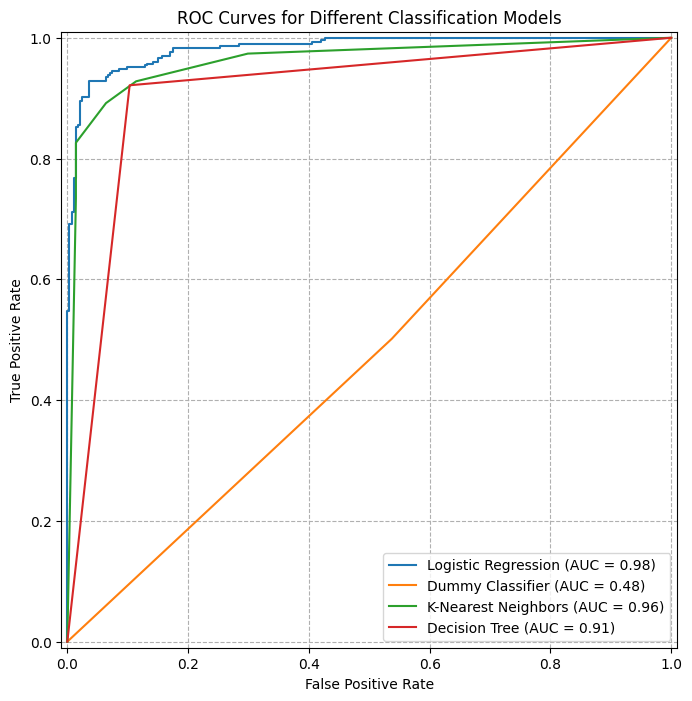

In [13]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

# Plot ROC for Logistic Regression
RocCurveDisplay.from_estimator(log_reg_model, X_test_scaled_df, y_test_binary, name='Logistic Regression', ax=plt.gca())

# Plot ROC for Dummy Classifier (using stratified to get probabilities)
dummy_model_proba = DummyClassifier(strategy='stratified', random_state=42)
dummy_model_proba.fit(X_train_scaled_df, y_train_binary)
RocCurveDisplay.from_estimator(dummy_model_proba, X_test_scaled_df, y_test_binary, name='Dummy Classifier', ax=plt.gca())

# Plot ROC for K-Nearest Neighbors
RocCurveDisplay.from_estimator(knn_model, X_test_scaled_df, y_test_binary, name='K-Nearest Neighbors', ax=plt.gca())

# Plot ROC for Decision Tree
RocCurveDisplay.from_estimator(dt_model, X_test_scaled_df, y_test_binary, name='Decision Tree', ax=plt.gca())

plt.title('ROC Curves for Different Classification Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid(linestyle='--')
plt.legend()
plt.show()

### 0.4 Cross-Validation for Logistic Regression

Cross-validation is a robust technique to assess a model's performance by training and testing on different subsets of the data. We'll use 5-fold stratified cross-validation for our logistic regression model to get a more reliable estimate of its generalization capability.

```markdown
*conduct 5-fold cross validation on the training data only*
```
___

In [14]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Initialize StratifiedKFold
# n_splits=5 for 5-fold cross-validation
# shuffle=True to randomize the data before splitting
# random_state for reproducibility
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation on the training data (X_train_scaled_df, y_train_binary)
# We'll use the already trained log_reg_model, but cross_val_score re-fits the model on each fold
cv_scores = cross_val_score(log_reg_model, X_train_scaled_df, y_train_binary, cv=skf, scoring='accuracy')

print(f"Cross-validation scores (accuracy): {cv_scores}")
print(f"Mean cross-validation accuracy: {cv_scores.mean():.4f}")
print(f"Standard deviation of cross-validation accuracy: {cv_scores.std():.4f}")

Cross-validation scores (accuracy): [0.92324094 0.91471215 0.90618337 0.89978678 0.91239316]
Mean cross-validation accuracy: 0.9113
Standard deviation of cross-validation accuracy: 0.0079


# Bootstrap Example

True Alpha: 0.60
Population Sim Mean: 0.5994, SE: 0.0841
Bootstrap Sim Mean:  0.5063, SE: 0.1052


/tmp/ipykernel_1020/56492468.py:84: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(['True', 'Bootstrap'])


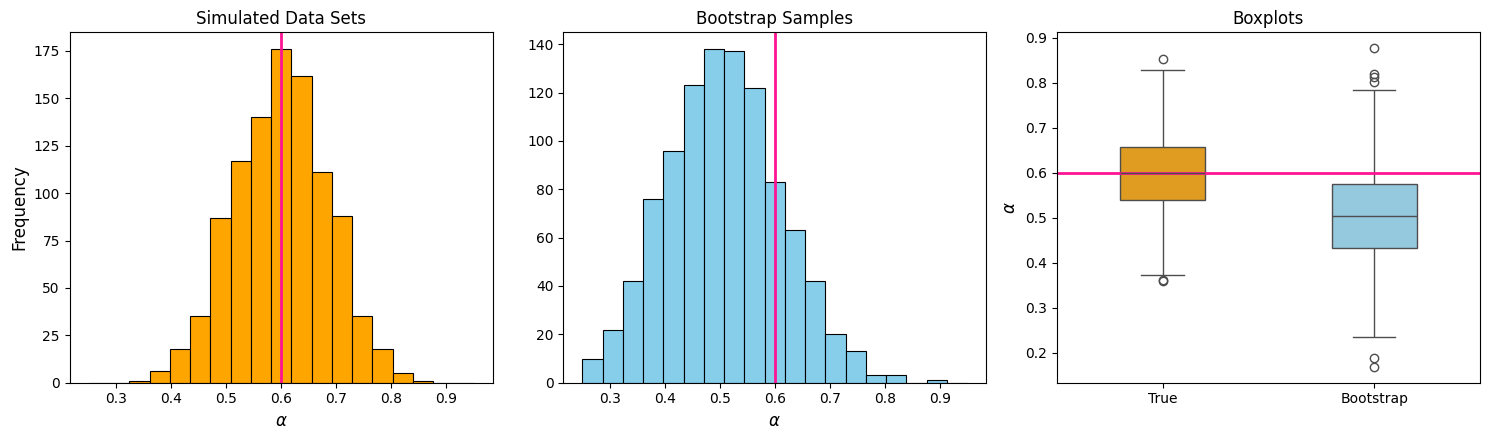

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set seed for reproducibility
np.random.seed(42)

# --- 1. Parameter Definitions ---
# True parameters given in Section 5.2
var_X = 1.0     # sigma^2_X
var_Y = 1.25    # sigma^2_Y
cov_XY = 0.5    # sigma_XY
true_alpha = (var_Y - cov_XY) / (var_X + var_Y - 2 * cov_XY) # True alpha = 0.6

# Construct Covariance Matrix
cov_matrix = [[var_X, cov_XY],
              [cov_XY, var_Y]]
mean = [0, 0]

def compute_alpha(data):
    """Calculates alpha_hat using sample variances and covariance from formula (5.7)."""
    X = data[:, 0]
    Y = data[:, 1]

    var_x_hat = np.var(X, ddof=1)
    var_y_hat = np.var(Y, ddof=1)
    cov_xy_hat = np.cov(X, Y)[0, 1]

    alpha_hat = (var_y_hat - cov_xy_hat) / (var_x_hat + var_y_hat - 2 * cov_xy_hat)
    return alpha_hat

# --- 2. Simulation 1: True Population Sampling (Left Panel) ---
n_samples = 100
n_simulations = 1000

simulated_alphas = []
for _ in range(n_simulations):
    data_sim = np.random.multivariate_normal(mean, cov_matrix, size=n_samples)
    simulated_alphas.append(compute_alpha(data_sim))

simulated_alphas = np.array(simulated_alphas)

# --- 3. Simulation 2: Bootstrap Sampling from One Original Dataset (Center Panel) ---
# Generate one single "original" dataset of size n=100
original_data = np.random.multivariate_normal(mean, cov_matrix, size=n_samples)

bootstrap_alphas = []
for _ in range(n_simulations):
    # Resample with replacement
    boot_indices = np.random.choice(n_samples, size=n_samples, replace=True)
    boot_data = original_data[boot_indices]
    bootstrap_alphas.append(compute_alpha(boot_data))

bootstrap_alphas = np.array(bootstrap_alphas)

# --- Print Summary Statistics ---
print(f"True Alpha: {true_alpha:.2f}")
print(f"Population Sim Mean: {np.mean(simulated_alphas):.4f}, SE: {np.std(simulated_alphas, ddof=1):.4f}")
print(f"Bootstrap Sim Mean:  {np.mean(bootstrap_alphas):.4f}, SE: {np.std(bootstrap_alphas, ddof=1):.4f}")

# --- 4. Plotting Figure 5.10 ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Common bin edges to align histograms
bins = np.linspace(0.25, 0.95, 20)

# Left Panel: True Population Simulations
axes[0].hist(simulated_alphas, bins=bins, color='orange', edgecolor='black', linewidth=0.8)
axes[0].axvline(true_alpha, color='deeppink', linestyle='-', linewidth=2)
axes[0].set_xlabel(r'$\alpha$', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Simulated Data Sets', fontsize=12)

# Center Panel: Bootstrap Samples
axes[1].hist(bootstrap_alphas, bins=bins, color='skyblue', edgecolor='black', linewidth=0.8)
axes[1].axvline(true_alpha, color='deeppink', linestyle='-', linewidth=2)
axes[1].set_xlabel(r'$\alpha$', fontsize=12)
axes[1].set_title('Bootstrap Samples', fontsize=12)

# Right Panel: Side-by-Side Boxplots
sns.boxplot(data=[simulated_alphas, bootstrap_alphas], ax=axes[2],
            palette=['orange', 'skyblue'], width=0.4)
axes[2].axhline(true_alpha, color='deeppink', linestyle='-', linewidth=2)
axes[2].set_xticklabels(['True', 'Bootstrap'])
axes[2].set_ylabel(r'$\alpha$', fontsize=12)
axes[2].set_title('Boxplots', fontsize=12)

plt.tight_layout()
plt.show()

--- TASK A: LINEAR REGRESSION ---
Intercept (Beta_0): 40.94
Slope (Beta_1):     5.28
Test MSE:           16.34
Test R^2 Score:     0.93

--- TASK B: LOGISTIC REGRESSION ---
Intercept (Beta_0): -7.68
Slope (Beta_1):     1.32
Test Accuracy:      0.85

Confusion Matrix:
[[8 0]
 [3 9]]


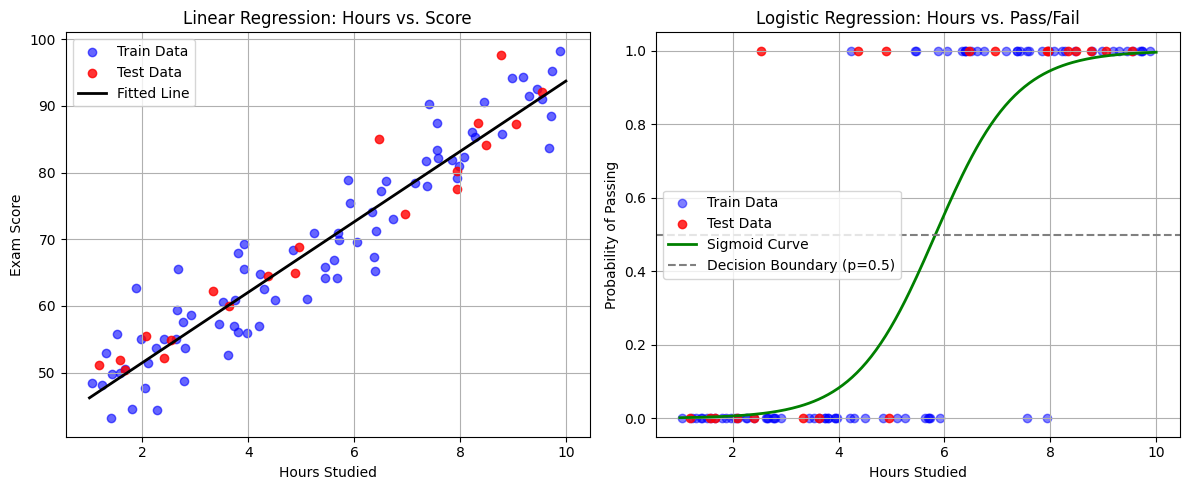

In [16]:
# ==========================================
# Google Colab Setup & Dependencies
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix, classification_report

# Set random seed for reproducibility
np.random.seed(42)

# ------------------------------------------
# Task A: Linear Regression (Continuous Y)
# ------------------------------------------
print("--- TASK A: LINEAR REGRESSION ---")

# 1. Generate synthetic dataset: Hours Studied vs. Exam Score (0-100)
X_linear = np.random.uniform(1, 10, 100).reshape(-1, 1)
# True relationship: Score = 40 + 5.5 * Hours + Noise
y_linear = 40 + 5.5 * X_linear.squeeze() + np.random.normal(0, 5, 100)

# Train-Test Split
X_train_lin, X_test_lin, y_train_lin, y_test_lin = train_test_split(
    X_linear, y_linear, test_size=0.2, random_state=42
)

# 2. Fit Linear Regression Model
lin_model = LinearRegression()
lin_model.fit(X_train_lin, y_train_lin)

# Predictions & Metrics
y_pred_lin = lin_model.predict(X_test_lin)
print(f"Intercept (Beta_0): {lin_model.intercept_:.2f}")
print(f"Slope (Beta_1):     {lin_model.coef_[0]:.2f}")
print(f"Test MSE:           {mean_squared_error(y_test_lin, y_pred_lin):.2f}")
print(f"Test R^2 Score:     {r2_score(y_test_lin, y_pred_lin):.2f}\n")

# 3. Plotting Linear Regression
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_train_lin, y_train_lin, color='blue', alpha=0.6, label='Train Data')
plt.scatter(X_test_lin, y_test_lin, color='red', alpha=0.8, label='Test Data')
X_range = np.linspace(1, 10, 100).reshape(-1, 1)
plt.plot(X_range, lin_model.predict(X_range), color='black', linewidth=2, label='Fitted Line')
plt.title("Linear Regression: Hours vs. Score")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.legend()
plt.grid(True)


# ------------------------------------------
# Task B: Logistic Regression (Binary Y)
# ------------------------------------------
print("--- TASK B: LOGISTIC REGRESSION ---")

# 1. Generate synthetic dataset: Hours Studied vs. Pass/Fail (0 or 1)
# Probability of passing increases with study hours
probabilities = 1 / (1 + np.exp(-(X_linear.squeeze() - 5.5)))
y_logistic = np.random.binomial(1, probabilities)

# Train-Test Split
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(
    X_linear, y_logistic, test_size=0.2, random_state=42
)

# 2. Fit Logistic Regression Model
log_model = LogisticRegression()
log_model.fit(X_train_log, y_train_log)

# Predictions & Metrics
y_pred_log = log_model.predict(X_test_log)
print(f"Intercept (Beta_0): {log_model.intercept_[0]:.2f}")
print(f"Slope (Beta_1):     {log_model.coef_[0][0]:.2f}")
print(f"Test Accuracy:      {accuracy_score(y_test_log, y_pred_log):.2f}\n")
print("Confusion Matrix:")
print(confusion_matrix(y_test_log, y_pred_log))

# 3. Plotting Logistic Regression Sigmoid Curve
plt.subplot(1, 2, 2)
plt.scatter(X_train_log, y_train_log, color='blue', alpha=0.5, label='Train Data')
plt.scatter(X_test_log, y_test_log, color='red', alpha=0.8, label='Test Data')

# Compute predicted probabilities over a smooth range
X_smooth = np.linspace(1, 10, 200).reshape(-1, 1)
y_prob_smooth = log_model.predict_proba(X_smooth)[:, 1]

plt.plot(X_smooth, y_prob_smooth, color='green', linewidth=2, label='Sigmoid Curve')
plt.axhline(0.5, color='gray', linestyle='--', label='Decision Boundary (p=0.5)')
plt.title("Logistic Regression: Hours vs. Pass/Fail")
plt.xlabel("Hours Studied")
plt.ylabel("Probability of Passing")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()